# Phase D — Reward model (Bradley-Terry)

1. Load 5k heuristic-labeled preference pairs.
2. Train a `RewardMLP` (28 + 4 → 256 → 256 → 1) for 20 epochs.
3. Plot train/val loss + val accuracy.
4. Histogram `r_A - r_B` partitioned by labeler preference.
5. Heldout evaluation: 1000 fresh pairs (seeds 90000…), heuristic vs reward-model preference agreement.

Run with `uv run jupyter nbconvert --to notebook --execute notebooks/05_reward_model.ipynb`.

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path('.').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from billiards.preference.dataset import load_pairs
from billiards.reward_model import RewardMLP, train, make_dataset

PAIRS_PATH = PROJECT_ROOT / 'data' / 'preference_pairs_5k.jsonl'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print('pairs path:', PAIRS_PATH, 'exists?', PAIRS_PATH.exists())

pairs path: /Users/ohdoyoel/work/side/cs377/project/data/preference_pairs_5k.jsonl exists? True


## 1. Load pairs and inspect distribution

In [2]:
pairs = load_pairs(PAIRS_PATH)
print(f'loaded {len(pairs)} pairs')
dist = Counter(p.preference for p in pairs)
print('distribution:', dict(dist))

loaded 5000 pairs
distribution: {'A': 1804, 'tie': 1389, 'B': 1807}


## 2. Train

In [3]:
model, history = train(
    pairs,
    epochs=20,
    lr=3e-4,
    batch_size=256,
    val_frac=0.15,
    seed=0,
    save_dir=MODELS_DIR,
    verbose=True,
)
print('final val_acc:', history['val_acc'][-1])

epoch  1/20  train_loss=0.6860  val_loss=0.6817  val_acc=0.424


epoch  2/20  train_loss=0.6724  val_loss=0.6739  val_acc=0.435


epoch  3/20  train_loss=0.6613  val_loss=0.6608  val_acc=0.471


epoch  4/20  train_loss=0.6465  val_loss=0.6464  val_acc=0.491


epoch  5/20  train_loss=0.6327  val_loss=0.6363  val_acc=0.483


...

epoch 17/20  train_loss=0.5851  val_loss=0.5858  val_acc=0.561


epoch 18/20  train_loss=0.5829  val_loss=0.5841  val_acc=0.552


epoch 19/20  train_loss=0.5794  val_loss=0.5856  val_acc=0.544


epoch 20/20  train_loss=0.5788  val_loss=0.5830  val_acc=0.540


final val_acc: 0.5400000214576721


## 3. Loss / accuracy curves

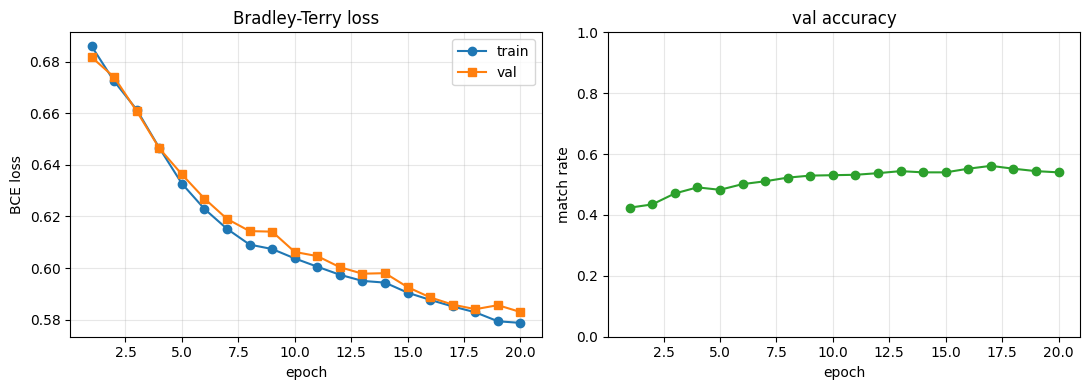

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ep = list(range(1, len(history['train_loss']) + 1))
axes[0].plot(ep, history['train_loss'], label='train', marker='o')
axes[0].plot(ep, history['val_loss'], label='val', marker='s')
axes[0].set_title('Bradley-Terry loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ep, history['val_acc'], color='tab:green', marker='o')
axes[1].set_title('val accuracy')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('match rate'); axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Histogram of `r_A - r_B` by labeler preference

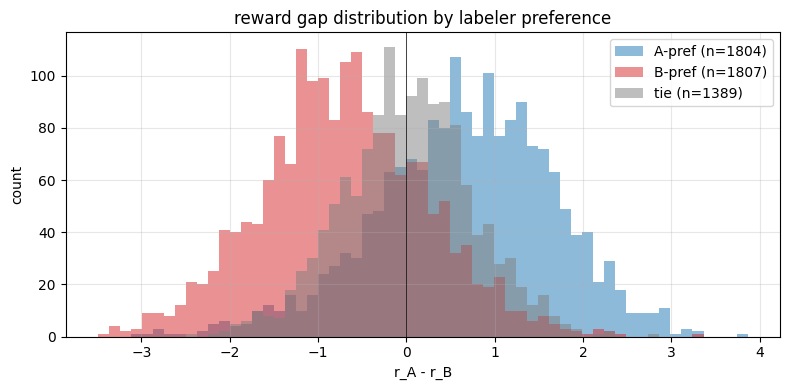

mean r_A-r_B (A-pref): 0.6659629940986633
mean r_A-r_B (B-pref): -0.6975601315498352
mean r_A-r_B (tie): 0.02112068608403206


In [5]:
model.eval()
s, aA, aB, y = make_dataset(pairs)
with torch.no_grad():
    diffs = (model(s, aA).squeeze(-1) - model(s, aB).squeeze(-1)).cpu().numpy()
labels = y.cpu().numpy()
diff_A = diffs[labels == 1.0]
diff_B = diffs[labels == 0.0]
diff_tie = diffs[labels == 0.5]
plt.figure(figsize=(8, 4))
bins = np.linspace(diffs.min(), diffs.max(), 60)
plt.hist(diff_A, bins=bins, alpha=0.5, label=f'A-pref (n={len(diff_A)})', color='tab:blue')
plt.hist(diff_B, bins=bins, alpha=0.5, label=f'B-pref (n={len(diff_B)})', color='tab:red')
plt.hist(diff_tie, bins=bins, alpha=0.5, label=f'tie (n={len(diff_tie)})', color='tab:gray')
plt.axvline(0, color='black', lw=0.5)
plt.xlabel('r_A - r_B'); plt.ylabel('count'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('reward gap distribution by labeler preference')
plt.tight_layout(); plt.show()
print('mean r_A-r_B (A-pref):', float(np.mean(diff_A)) if len(diff_A) else float('nan'))
print('mean r_A-r_B (B-pref):', float(np.mean(diff_B)) if len(diff_B) else float('nan'))
print('mean r_A-r_B (tie):',   float(np.mean(diff_tie)) if len(diff_tie) else float('nan'))

## 5. Held-out evaluation: 1000 fresh pairs (seeds 90000–91000)

In [6]:
from billiards.env import Billiards4BallEnv
from billiards.inning_env import Billiards4BallInningEnv
from billiards.preference.dataset import _result_digest, _sample_random_action, PreferencePair
from billiards.preference.labeler_heuristic import label_pair_heuristic
import uuid

def make_holdout(env_kind, seed):
    env_cls = Billiards4BallEnv if env_kind == 'single' else Billiards4BallInningEnv
    env_kwargs = {} if env_kind == 'single' else {'max_shots': 1}
    rng = np.random.default_rng(seed * 7919 + 1)
    eA = env_cls(**env_kwargs); obs, _ = eA.reset(seed=seed)
    aA = _sample_random_action(rng); _, _, _, _, infoA = eA.step(aA)
    eB = env_cls(**env_kwargs); eB.reset(seed=seed)
    aB = _sample_random_action(rng); _, _, _, _, infoB = eB.step(aB)
    pair = PreferencePair(
        pair_id=uuid.uuid4().hex,
        initial_state=[float(v) for v in np.asarray(obs).reshape(-1).tolist()],
        action_A=[float(v) for v in aA.tolist()],
        action_B=[float(v) for v in aB.tolist()],
        result_A=_result_digest(infoA),
        result_B=_result_digest(infoB),
        preference=None, labeler='unlabeled',
        label_meta={'seed': seed, 'env_kind': env_kind},
    )
    return label_pair_heuristic(pair)

holdout = []
for k in range(1000):
    kind = 'single' if (k % 2 == 0) else 'inning'
    holdout.append(make_holdout(kind, 90000 + k))
print(f'made {len(holdout)} held-out pairs')
print('heuristic distribution:', Counter(p.preference for p in holdout))

made 1000 held-out pairs
heuristic distribution: Counter({'A': 359, 'B': 345, 'tie': 296})


In [7]:
s_h, aA_h, aB_h, y_h = make_dataset(holdout)
model.eval()
with torch.no_grad():
    rA = model(s_h, aA_h).squeeze(-1)
    rB = model(s_h, aB_h).squeeze(-1)
    diff = (rA - rB).cpu().numpy()
pred = np.where(np.abs(diff) < 1e-3, 0.5, (diff > 0).astype(float))
true = y_h.cpu().numpy()
agreement = float((pred == true).mean())
print(f'held-out agreement vs heuristic: {agreement:.3f}')
non_tie = true != 0.5
if non_tie.any():
    nt_agree = float((pred[non_tie] == true[non_tie]).mean())
    print(f'agreement on non-tie subset: {nt_agree:.3f} (n={int(non_tie.sum())})')

held-out agreement vs heuristic: 0.543
agreement on non-tie subset: 0.771 (n=704)


## 6. Verdict

In [8]:
print(
    f'VERDICT: trained 5k pairs, final val_acc={history["val_acc"][-1]:.3f}, '
    f'held-out heuristic agreement={agreement:.3f}'
)

VERDICT: trained 5k pairs, final val_acc=0.540, held-out heuristic agreement=0.543
